In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Any, List, Dict, Union
from os.path import exists

import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR

import xgboost as xgb

In [26]:
def read_sheet(path) -> np.ndarray:
    """Reads the spreadsheet and converts to a numpy array."""
    return pd.read_csv(path).to_numpy()

def feats_targs(root: str) -> Tuple[np.ndarray, np.ndarray]:
    """Returns the features and targets in the given folder."""
    return (
        read_sheet(root + 'feats.ignore.csv'), 
        read_sheet(root + 'targs.ignore.csv').T[0]
    )

train_feats, train_targs = feats_targs('../../../src/ml/data/train/')
valid_feats, valid_targs = feats_targs('../../../src/ml/data/valid/')

poly = PolynomialFeatures(degree=2)
poly_train = poly.fit_transform(train_feats)
poly_valid = poly.fit_transform(valid_feats)

scale = StandardScaler()
scale_train = scale.fit_transform(train_feats)
scale_valid = scale.fit_transform(valid_feats)

scale = StandardScaler()
scale_poly_train = scale.fit_transform(poly_train)
scale_poly_valid = scale.fit_transform(poly_valid)


In [27]:
def mse(X: np.ndarray, Y: np.ndarray) -> float:
    """Returns the mean squared error between X and Y."""
    res = 0
    l = min(len(X), len(Y))
    for i in range(l):
        res += (X[i] - Y[i]) ** 2
    return res / l

In [28]:
def get_path(model_name: str) -> str:
    """Returns the path to the model's prediction plot."""
    return f'plots/{model_name}.png'

def plot_preds(preds: np.ndarray, model_name: str):
    """Prints the predictions against the validation targets."""
    err = mse(valid_targs, preds)
    f = plt.figure()
    ax = f.add_subplot(111)

    plt.clf()
    plt.title('Predicted run value vs actual')
    plt.xlabel('Actual run value')
    plt.ylabel('Predicted run value')
    plt.scatter(valid_targs, preds)

    _, ymax = plt.ylim()
    plt.ylim(top = ymax * 1.3)
    plt.text(
        0.2, 
        0.9, 
        'mse = {:.6f}'.format(err), 
        ha = 'center', 
        va = 'center',
        transform = ax.transAxes
    )

    plt.savefig(get_path(model_name))

def plot_model(
    model: sklearn.base.BaseEstimator, 
    name: str, 
    grid: Union[List[Dict[str, List[Any]]], Dict[str, List[Any]], None] = None,
    force: bool = True
):
    """Trains the model and plots its predictions."""
    path = get_path(name)
    if exists(path) and not force:
        print('Skipping plotting...')
        return
        
    if grid is None:
        reg = model
    else:
        reg = GridSearchCV(
            model,
            grid,
            n_jobs=8
        )
    reg.fit(train_feats, train_targs)
    print(mse(reg.predict(train_feats), train_targs))
    plot_preds(reg.predict(valid_feats), name)


0.07190787337021788


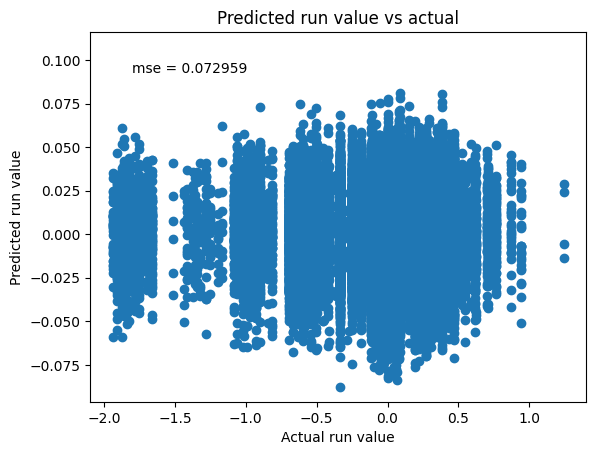

In [29]:
def test_knn(algorithm: str):
    """Plots the KNN model with the given algorothm."""
    knn = KNeighborsRegressor(
        algorithm=algorithm,
        n_neighbors=200,
        leaf_size=200
    )
    plot_model(
        knn,
        algorithm,
        # grid={'n_neighbors': [50, 100, 200], 'leaf_size': [50, 100, 200]}
    )

test_knn('kd_tree')

0.07190787337021788


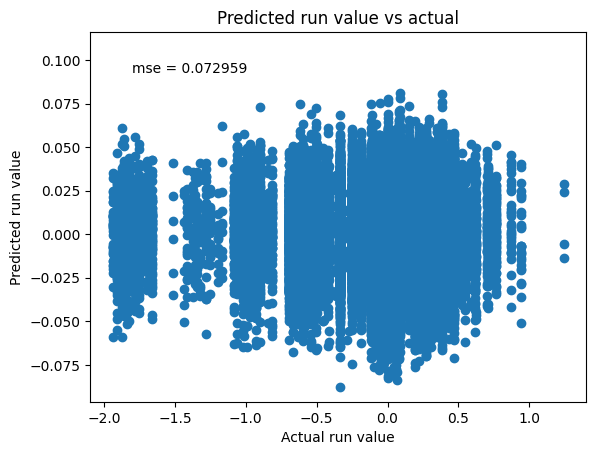

In [30]:
test_knn('kd_tree')

0.07105130286528497


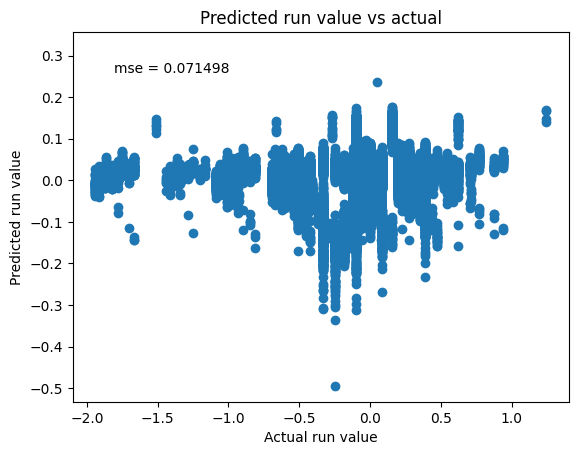

In [31]:
def plot_from_features(
    model: sklearn.base.BaseEstimator, 
    train_feats: np.ndarray,
    valid_feats: np.ndarray,
    name: str,
    grid: Union[List[Dict[str, List[Any]]], Dict[str, List[Any]], None] = None,
    force = True
):
    if not exists(get_path(name)) or force:
        if grid is None:
            reg = model
        else:
            reg = GridSearchCV(
                model,
                grid,
                n_jobs=8
            )

        reg.fit(train_feats, train_targs)
        print(mse(reg.predict(train_feats), train_targs))
        plot_preds(reg.predict(valid_feats), name)
        
    else: 
        print('Skipping plotting...')

regression = LinearRegression(fit_intercept=False)
plot_from_features(
    regression,
    poly_train,
    poly_valid,
    'polynomial_regression',
)


0.06985563184150523


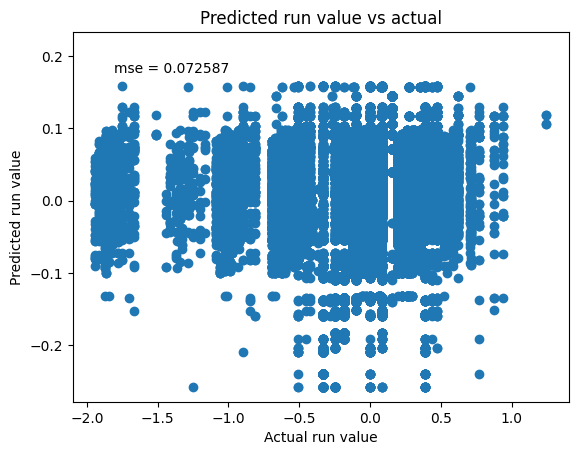

In [32]:
dec_tree = DecisionTreeRegressor(
    min_samples_leaf=200
)
plot_model(
    dec_tree, 
    'decision_tree',
    # grid={'min_samples_leaf': [50, 100, 200]}
)

0.06971875026980939


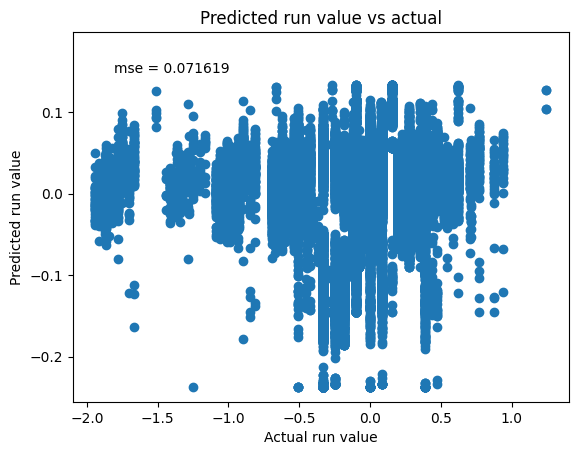

In [33]:
forest = RandomForestRegressor(
    n_estimators=30,
    min_samples_leaf=200
)
plot_model(
    forest, 
    'random_forest',
    # grid={'n_estimators': [10, 30, 100], 'min_samples_leaf': [50, 100, 200]}
)

0.06978474386426235


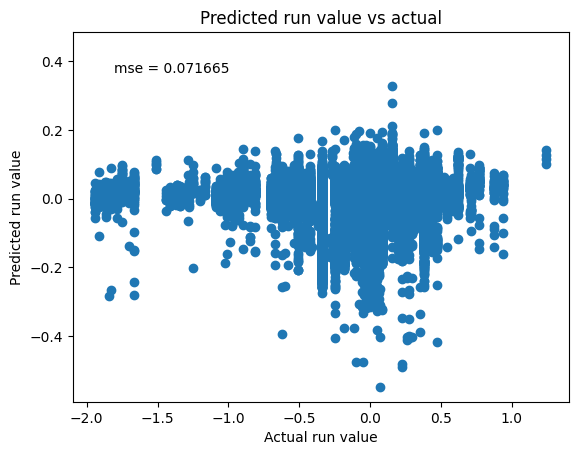

In [34]:
boost = xgb.XGBRegressor(
    n_estimators=30,
    max_depth=6,
)
plot_model(
    boost, 
    'xgboost', 
    # grid={'max_depth': [2, 4, 6], 'n_estimators': [50, 100, 200]}
)

0.07166739524198265


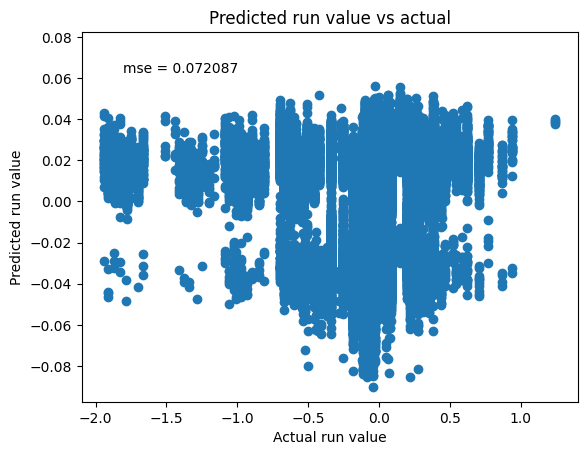

In [35]:
ridge = Ridge(

)

plot_from_features(
    ridge,
    scale_train,
    scale_valid,
    'ridge',
    grid={'alpha': [0.25, 0.5, 0.75]},
    force=True
)

0.07219284038640784


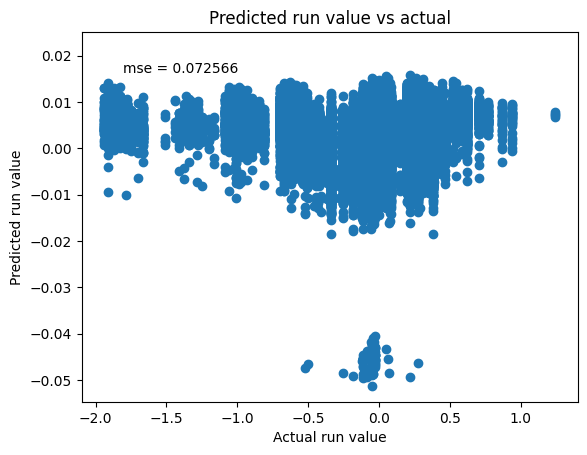

In [36]:
sgd = SGDRegressor(
    
)

scaler = StandardScaler()

plot_from_features(
    sgd,
    scale_train,
    scale_valid,
    'gradient_descent',
    grid={'alpha': 10.0 ** np.arange(1, 7)}
)